In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.nice(19)

19

In [2]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as pl
from astropy import constants as c
%matplotlib inline

#styling
import seaborn as sns
sns.set_style(style='ticks', rc=None)
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})

matplotlib.rcParams.update({'font.size': 20})
pl.rcParams['ytick.labelsize'] = 'large'
pl.rcParams['xtick.labelsize'] = 'large'
fontsize=20

[]

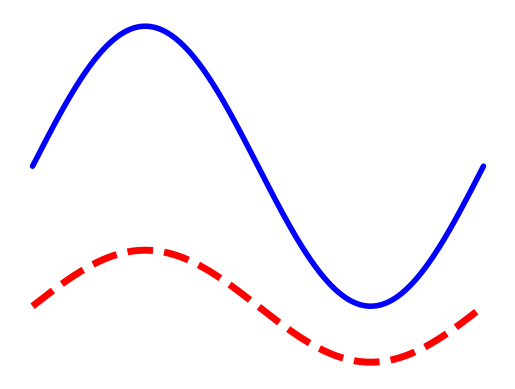

In [3]:
x = np.linspace(0, 2 * np.pi, 1000) 
#y = np.sin(x)  + 2 * np.sin(1.2*x-3) 


fig, ax = pl.subplots()
ax.plot(x, 0.4*np.sin(x)-1, lw = 5, color='red', linestyle='--')
ax.plot(x, np.sin(x), lw = 4, color='blue')

ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

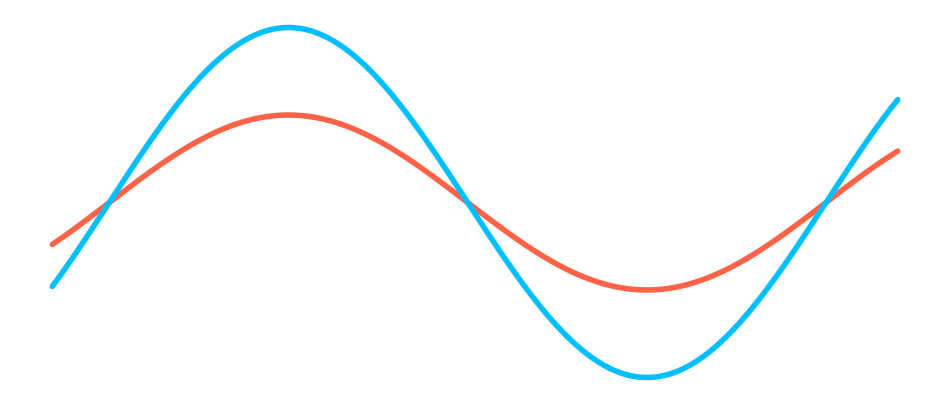

In [4]:
x = np.linspace(-0.5, 2.2 * np.pi, 1000) 
#y = np.sin(x)  + 2 * np.sin(1.2*x-3) 


fig, ax = pl.subplots(figsize=(12, 5))
ax.plot(x, 0.5*np.sin(x), lw = 4, color='tomato')
ax.plot(x, np.sin(x), lw = 4, color='deepskyblue')

ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

fig.savefig('lc_color.png')

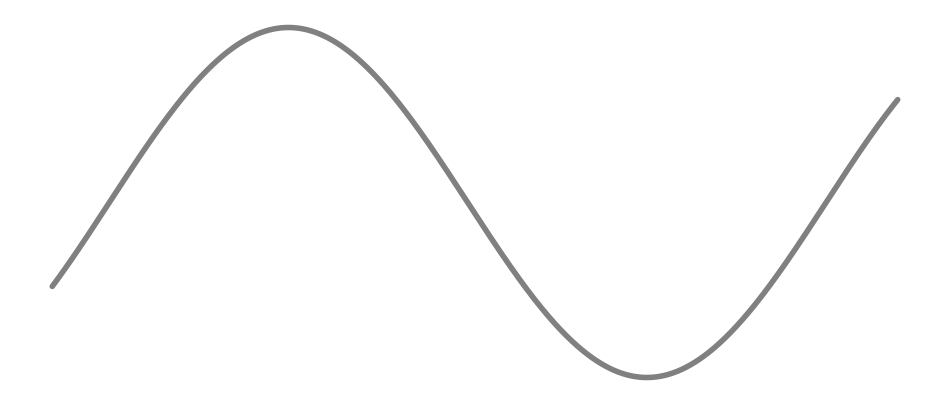

In [5]:
x = np.linspace(-0.5, 2.2 * np.pi, 1000) 
#y = np.sin(x)  + 2 * np.sin(1.2*x-3) 


fig, ax = pl.subplots(figsize=(12, 5))
ax.plot(x, np.sin(x), lw = 4, color='gray')

ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

fig.savefig('lc_mono.png')

[]

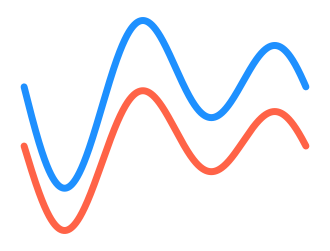

In [109]:
x = np.linspace(0, 2 * np.pi, 1000) 
y = np.sin(1.2*x-np.pi) + np.sin(1.8*x-np.pi) + np.sin(2*x-np.pi) 


fig, ax = pl.subplots(figsize=(4, 3))
ax.plot(x, 1.2*y, lw = 5, color='dodgerblue')
ax.plot(x, y-2, lw = 5, color='tomato')

ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

[]

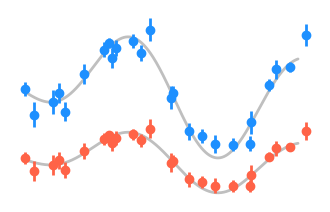

In [167]:
fig, ax = pl.subplots(figsize=(4,2.5))

rng = np.random.default_rng(0)

x = np.linspace(0, 2 * np.pi, 1000)
y = np.sin(x) + np.sin(1.8*x-np.pi) 

ax.plot(x, 2*y, lw = 2, color='gray', alpha=0.5)
ax.plot(x, y-4, lw = 2, color='gray', alpha=0.5)

# 観測点
n_obs = 25
x_obs = np.linspace(0, 2*np.pi, n_obs)
x_obs += rng.normal(0, 0.2, n_obs)   # x方向のばらつき
x_obs = np.sort(x_obs)

y_obs = np.sin(x_obs) + np.sin(1.8*x_obs-np.pi) 

yerr = rng.uniform(0.2, 0.6, n_obs)  # 各点の観測誤差
y_obs_noisy = y_obs + 0.7*rng.normal(0, yerr)

ax.errorbar(
    x_obs, 2*y_obs_noisy,
    yerr=1.2*yerr,
    fmt='o',
    ms=6,
    lw=2,
    capsize=0,
    color='dodgerblue'
)

ax.errorbar(
    x_obs, y_obs_noisy-4,
    yerr=yerr,
    fmt='o',
    ms=6,
    lw=2,
    capsize=0,
    color='tomato'
)

ax.axis('off')
ax.set_xticks([])
ax.set_yticks([])

[]

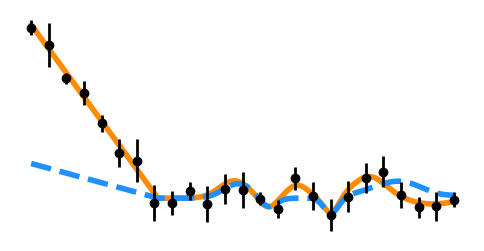

In [218]:
fig, ax = pl.subplots(figsize=(6,3))

x = np.linspace(0, 10, 500)

# 左だけ下降し、その後は一定
baseline = -2. * np.minimum(x, 3)

def g(x, mu, sig, amp):
    return amp * np.exp(-(x-mu)**2/(2*sig**2))

y = (
    baseline
    + g(x, 4.8, 0.35, 0.6)
    - g(x, 5.6, 0.20, 0.35)
    + g(x, 6.3, 0.25, 0.45)
    - g(x, 7.1, 0.18, 0.55)
    + g(x, 8.0, 0.40, 0.75)
    - g(x, 9.5, 0.50, 0.20)
)

pl.plot(x,y, lw=4, color="darkorange")

y_base = (
    0.2*baseline
    + g(x, 4.9, 0.35, 0.5)
    - g(x, 5.6, 0.20, 0.35)
    - g(x, 7.1, 0.18, 0.55)
    + g(x, 9.0, 0.80, 0.75)
    - g(x, 9.5, 0.50, 0.40)
)

pl.plot(x,y_base-4.8, color='dodgerblue', ls='--', lw=4)

n_obs = 25
x_obs = np.linspace(0, 10, n_obs)
#x_obs += rng.normal(0, 0.4, n_obs)   # x方向のばらつき
x_obs = np.sort(x_obs)

baseline_obs = -2. * np.minimum(x_obs, 3)

y_obs = (
    baseline_obs
    + g(x_obs, 4.8, 0.35, 0.6)
    - g(x_obs, 5.6, 0.20, 0.35)
    + g(x_obs, 6.3, 0.25, 0.45)
    - g(x_obs, 7.1, 0.18, 0.55)
    + g(x_obs, 8.0, 0.40, 0.75)
    - g(x_obs, 9.5, 0.50, 0.20)
)

yerr = rng.uniform(0.2,0.8, n_obs)  # 各点の観測誤差
y_obs_noisy = y_obs + 0.5*rng.normal(0, yerr)

pl.errorbar(x_obs,y_obs_noisy,yerr, fmt='o',    
    ms=6,
    lw=2,
    capsize=0,
    color='k')


ax.axis('off')

ax.set_xticks([])
ax.set_yticks([])
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])